# Comparison of SGS kinetic-energy spectra



In [1]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# Expected notebook location:
# THESIS/z.flow_postprocessing/notebooks/compare_SGS_spectra_two_panel.ipynb
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
OGCM_SCRIPTS_DIR = PROJECT_DIR / "OGCM" / "scripts"

for path in [PROJECT_DIR, OGCM_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme

importlib.reload(ptheme)
ptheme.apply_theme()

print(f"Notebook dir : {NB_DIR}")
print(f"Project dir  : {PROJECT_DIR}")


Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir  : C:\Users\Jelle Gortemaker\Documents\Thesis


In [2]:
# ============================================================
# 2. COMPARISON SETTINGS
# ============================================================

SEASON_LABEL = "January"

# Five moderate SGS configurations.
# Adjust only the case names if your local naming differs.
CASE_NAMES = {
    "Constant harmonic": "run_SGS_C1_win",
    "Smagorinsky": "run_SGS_S1_win",
    "Leith": "run_SGS_L1_win",
}

INPUT_DIR = (NB_DIR / "../data/input").resolve()
RESULTS_DIR = (
    NB_DIR / "../results/SGS_spectral_comparison"
).resolve()

SAVE = True


# ------------------------------------------------------------
START_DAY = 7.0
END_DAY = 7.0

# Used only when the NetCDF time coordinate does not contain usable units.
FALLBACK_OUTPUT_INTERVAL_HOURS = 12.0

LAYER_INDEX = 0

X_RES_M = 500.0
Y_RES_M = 500.0

N_BINS = 20
MIN_MODES_PER_BIN = 3
REMOVE_MEAN = True

SHOW_STD_BANDS = True
SHOW_REFERENCE_SLOPES = True

XLIM_LENGTH_KM = None
XLIM_WAVENUMBER = None

YLIM_SHELL = (1.0e-8, 1.0e-2)
YLIM_DENSITY = (1.0e-4, 1.0e4)

# These bands are summarized in a table below the figure.
SPECTRAL_BANDS_KM = {
    "Submesoscale": (1.0, 20.0),
    "Mesoscale": (20.0, 110.0),
}

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input directory : {INPUT_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Analysis window : {START_DAY:g}--{END_DAY:g} days")


Input directory : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input
Results directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\SGS_spectral_comparison
Analysis window : 7--7 days


In [3]:
# ============================================================
# 3. SPECTRAL CALCULATION HELPERS
# ============================================================

def infer_depth_dim(ds):
    for dim in ds.dims:
        if dim.startswith("Z") or "depth" in dim.lower():
            return dim

    raise ValueError(
        f"No depth-like dimension found. Available dims: {list(ds.dims)}"
    )


def infer_time_dim(ds):
    for dim in ["T", "time", "Time", "iter"]:
        if dim in ds.dims:
            return dim

    for dim in ds.dims:
        name = dim.lower()
        if name.startswith("t") or "time" in name:
            return dim

    raise ValueError(
        f"No time-like dimension found. Available dims: {list(ds.dims)}"
    )


def time_coordinate_to_days(ds, time_dim, fallback_interval_hours):
    """
    Convert the time coordinate to elapsed days from the first output.

    The conversion uses datetime coordinates or the coordinate's units
    attribute when possible. Otherwise, it falls back to a fixed output
    interval.
    """
    n_time = int(ds.sizes[time_dim])

    if time_dim not in ds.coords:
        return (
            np.arange(n_time, dtype=float)
            * float(fallback_interval_hours)
            / 24.0
        )

    time_da = ds[time_dim]
    values = np.asarray(time_da.values)

    if np.issubdtype(values.dtype, np.datetime64):
        return (
            (values - values[0]) / np.timedelta64(1, "D")
        ).astype(float)

    values = values.astype(float)
    units = str(time_da.attrs.get("units", "")).lower()

    if "second" in units:
        return (values - values[0]) / 86400.0

    if "hour" in units:
        return (values - values[0]) / 24.0

    if "day" in units:
        return values - values[0]

    # MITgcm MNC T is commonly stored in seconds even if the units
    # attribute is absent. Use that interpretation when the spacing
    # is clearly larger than one day expressed as a plain index.
    if values.size > 1:
        median_step = float(np.nanmedian(np.diff(values)))

        if median_step > 100.0:
            return (values - values[0]) / 86400.0

    return (
        np.arange(n_time, dtype=float)
        * float(fallback_interval_hours)
        / 24.0
    )


def select_time_indices(
    time_days,
    start_day,
    end_day,
):
    time_days = np.asarray(time_days, dtype=float)
    mask = np.isfinite(time_days)

    if start_day is not None:
        mask &= time_days >= float(start_day) - 1.0e-12

    if end_day is not None:
        mask &= time_days <= float(end_day) + 1.0e-12

    indices = np.flatnonzero(mask)

    if indices.size == 0:
        raise ValueError(
            "No snapshots fall inside the selected time window."
        )

    return indices


def calculate_window_eds(
    filepath,
    *,
    start_day,
    end_day,
    layer_index=0,
    x_res_m=500.0,
    y_res_m=500.0,
    n_bins=8,
    remove_mean=True,
    min_modes_per_bin=3,
    fallback_output_interval_hours=12.0,
):
    """
    Compute shell-integrated and density spectra for a fixed time window.

    The implementation follows the existing calculate_EDS_init logic but
    averages only the selected physical time range.
    """
    filepath = Path(filepath)

    with xr.open_dataset(
        filepath,
        decode_times=True,
        cache=False,
    ) as ds:
        if "UVEL" not in ds or "VVEL" not in ds:
            raise KeyError(
                f"{filepath.name} must contain UVEL and VVEL."
            )

        depth_dim = infer_depth_dim(ds)
        time_dim = infer_time_dim(ds)

        if layer_index < 0 or layer_index >= int(ds.sizes[depth_dim]):
            raise IndexError(
                f"layer_index={layer_index} is outside "
                f"0..{int(ds.sizes[depth_dim]) - 1}."
            )

        time_days = time_coordinate_to_days(
            ds,
            time_dim,
            fallback_output_interval_hours,
        )

        selected_indices = select_time_indices(
            time_days,
            start_day,
            end_day,
        )

        x = np.asarray(ds["X"].values, dtype=float)
        y = np.asarray(ds["Y"].values, dtype=float)

        nx = int(x.size)
        ny = int(y.size)

        dx = (
            float(np.nanmedian(np.diff(x)))
            if x.size > 1
            else float(x_res_m)
        )
        dy = (
            float(np.nanmedian(np.diff(y)))
            if y.size > 1
            else float(y_res_m)
        )

        if not np.isfinite(dx) or dx <= 0.0:
            dx = float(x_res_m)

        if not np.isfinite(dy) or dy <= 0.0:
            dy = float(y_res_m)

        Lx = nx * dx
        Ly = ny * dy

        kx = np.fft.fftfreq(nx, d=dx)
        ky = np.fft.fftfreq(ny, d=dy)
        kx_grid, ky_grid = np.meshgrid(
            kx,
            ky,
            indexing="xy",
        )

        k_mag = np.sqrt(kx_grid**2 + ky_grid**2)
        valid_k = k_mag > 0.0

        natural_lambda_max = min(Lx, Ly)
        k_min = 1.0 / natural_lambda_max
        k_max = float(np.nanmax(k_mag[valid_k]))

        k_edges = np.logspace(
            np.log10(k_min),
            np.log10(k_max),
            num=int(n_bins) + 1,
        )
        k_centers = np.sqrt(
            k_edges[:-1] * k_edges[1:]
        )
        dk = np.diff(k_edges)

        shell_masks = []
        shell_counts = np.zeros(int(n_bins), dtype=int)

        for bin_index in range(int(n_bins)):
            mask = (
                (k_mag >= k_edges[bin_index])
                & (k_mag < k_edges[bin_index + 1])
            )
            shell_masks.append(mask)
            shell_counts[bin_index] = int(np.count_nonzero(mask))

        shell_snapshots = []
        density_snapshots = []

        for time_index in selected_indices:
            u_face = np.asarray(
                ds["UVEL"].isel(
                    {
                        time_dim: int(time_index),
                        depth_dim: int(layer_index),
                    }
                ).values,
                dtype=float,
            ).squeeze()

            v_face = np.asarray(
                ds["VVEL"].isel(
                    {
                        time_dim: int(time_index),
                        depth_dim: int(layer_index),
                    }
                ).values,
                dtype=float,
            ).squeeze()

            if u_face.shape == (ny, nx + 1):
                u = 0.5 * (
                    u_face[:, :-1] + u_face[:, 1:]
                )
            elif u_face.shape == (ny, nx):
                u = u_face
            else:
                raise ValueError(
                    f"Unexpected UVEL shape {u_face.shape} "
                    f"in {filepath.name}."
                )

            if v_face.shape == (ny + 1, nx):
                v = 0.5 * (
                    v_face[:-1, :] + v_face[1:, :]
                )
            elif v_face.shape == (ny, nx):
                v = v_face
            else:
                raise ValueError(
                    f"Unexpected VVEL shape {v_face.shape} "
                    f"in {filepath.name}."
                )

            u = np.nan_to_num(u, nan=0.0)
            v = np.nan_to_num(v, nan=0.0)

            if remove_mean:
                u = u - np.mean(u)
                v = v - np.mean(v)

            u_hat = np.fft.fft2(u)
            v_hat = np.fft.fft2(v)

            n_points = nx * ny

            ke_2d = 0.5 * (
                np.abs(u_hat) ** 2
                + np.abs(v_hat) ** 2
            ) / (n_points ** 2)

            shell_spectrum = np.full(
                int(n_bins),
                np.nan,
                dtype=float,
            )
            density_spectrum = np.full(
                int(n_bins),
                np.nan,
                dtype=float,
            )

            for bin_index, shell_mask in enumerate(shell_masks):
                if shell_counts[bin_index] < int(min_modes_per_bin):
                    continue

                shell_sum = float(
                    np.nansum(ke_2d[shell_mask])
                )

                if not np.isfinite(shell_sum) or shell_sum <= 0.0:
                    continue

                shell_spectrum[bin_index] = shell_sum
                density_spectrum[bin_index] = (
                    shell_sum / dk[bin_index]
                )

            shell_snapshots.append(shell_spectrum)
            density_snapshots.append(density_spectrum)

    shell_snapshots = np.asarray(shell_snapshots)
    density_snapshots = np.asarray(density_snapshots)

    # Restrict radial bins to the Cartesian-grid Nyquist limit.
    nyquist = 1.0 / (2.0 * max(dx, dy))
    keep = k_centers <= nyquist

    return xr.Dataset(
        data_vars={
            "shell_integrated_spectrum": (
                ("wavenumber",),
                np.nanmean(shell_snapshots, axis=0)[keep],
            ),
            "shell_integrated_spectrum_std": (
                ("wavenumber",),
                np.nanstd(shell_snapshots, axis=0)[keep],
            ),
            "spectral_density": (
                ("wavenumber",),
                np.nanmean(density_snapshots, axis=0)[keep],
            ),
            "spectral_density_std": (
                ("wavenumber",),
                np.nanstd(density_snapshots, axis=0)[keep],
            ),
            "shell_mode_count": (
                ("wavenumber",),
                shell_counts[keep],
            ),
        },
        coords={
            "wavenumber": k_centers[keep],
            "characteristic_length": (
                ("wavenumber",),
                1.0 / k_centers[keep],
            ),
        },
        attrs={
            "source_file": str(filepath),
            "layer_index": int(layer_index),
            "start_day_requested": (
                np.nan if start_day is None else float(start_day)
            ),
            "end_day_requested": (
                np.nan if end_day is None else float(end_day)
            ),
            "first_selected_day": float(
                time_days[selected_indices[0]]
            ),
            "last_selected_day": float(
                time_days[selected_indices[-1]]
            ),
            "n_selected_snapshots": int(selected_indices.size),
            "dx_m": float(dx),
            "dy_m": float(dy),
            "domain_Lx_km": float(Lx / 1000.0),
            "domain_Ly_km": float(Ly / 1000.0),
            "remove_mean": bool(remove_mean),
        },
    ).dropna(dim="wavenumber", how="all")


In [4]:
# ============================================================
# 4. CALCULATE ALL FIVE WINDOW-AVERAGED SPECTRA
# ============================================================

spectra = {}

for display_name, case_name in CASE_NAMES.items():
    data_file = INPUT_DIR / f"{case_name}.nc"

    if not data_file.exists():
        raise FileNotFoundError(data_file)

    print(f"\nCalculating {display_name}: {data_file.name}")

    spectra[display_name] = calculate_window_eds(
        data_file,
        start_day=START_DAY,
        end_day=END_DAY,
        layer_index=LAYER_INDEX,
        x_res_m=X_RES_M,
        y_res_m=Y_RES_M,
        n_bins=N_BINS,
        remove_mean=REMOVE_MEAN,
        min_modes_per_bin=MIN_MODES_PER_BIN,
        fallback_output_interval_hours=(
            FALLBACK_OUTPUT_INTERVAL_HOURS
        ),
    )

    attrs = spectra[display_name].attrs

    print(
        "  selected snapshots : "
        f"{attrs['n_selected_snapshots']}"
    )
    print(
        "  selected days      : "
        f"{attrs['first_selected_day']:.3f} to "
        f"{attrs['last_selected_day']:.3f}"
    )

print("\nFinished calculating all spectra.")



Calculating Constant harmonic: run_SGS_C1_win.nc
  selected snapshots : 1
  selected days      : 7.000 to 7.000

Calculating Smagorinsky: run_SGS_S1_win.nc
  selected snapshots : 1
  selected days      : 7.000 to 7.000

Calculating Leith: run_SGS_L1_win.nc
  selected snapshots : 1
  selected days      : 7.000 to 7.000

Finished calculating all spectra.


C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_20428\3515150799.py:327: RuntimeWarning: Mean of empty slice
  np.nanmean(shell_snapshots, axis=0)[keep],
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_20428\3515150799.py:335: RuntimeWarning: Mean of empty slice
  np.nanmean(density_snapshots, axis=0)[keep],
C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_20428\3515150799.py:327: RuntimeWarning: Mean of empty slice
  np.nanmean(shell_snapshots, axis=0)[keep],
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_20428\35

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_20428\2549397606.py:132: RuntimeWarning: All-NaN slice encountered
  reference_mean = np.nanmedian(


Saved figure to: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\SGS_spectral_comparison\SGS_spectra_January_T7-7d.png


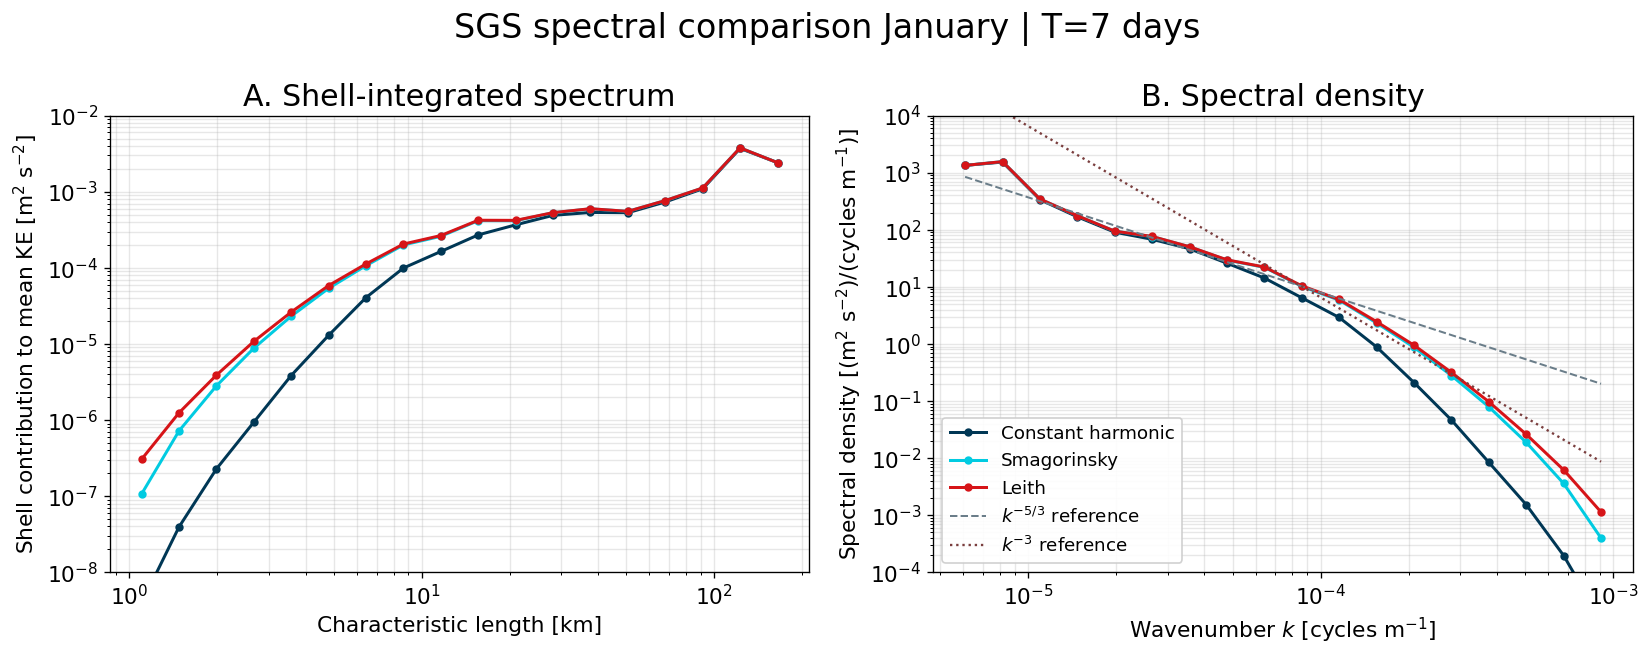

In [5]:
# ============================================================
# 5. TWO-PANEL SGS SPECTRAL COMPARISON
# ============================================================

fig, (ax_shell, ax_density) = plt.subplots(
    1,
    2,
    figsize=(14.0, 5.6),
)

for display_name, eds in spectra.items():
    length_km = (
        np.asarray(
            eds["characteristic_length"].values,
            dtype=float,
        )
        / 1000.0
    )
    wavenumber = np.asarray(
        eds["wavenumber"].values,
        dtype=float,
    )

    shell_mean = np.asarray(
        eds["shell_integrated_spectrum"].values,
        dtype=float,
    )
    shell_std = np.asarray(
        eds["shell_integrated_spectrum_std"].values,
        dtype=float,
    )

    density_mean = np.asarray(
        eds["spectral_density"].values,
        dtype=float,
    )
    density_std = np.asarray(
        eds["spectral_density_std"].values,
        dtype=float,
    )

    valid_shell = (
        np.isfinite(length_km)
        & np.isfinite(shell_mean)
        & (length_km > 0.0)
        & (shell_mean > 0.0)
    )

    valid_density = (
        np.isfinite(wavenumber)
        & np.isfinite(density_mean)
        & (wavenumber > 0.0)
        & (density_mean > 0.0)
    )

    shell_line, = ax_shell.loglog(
        length_km[valid_shell],
        shell_mean[valid_shell],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=display_name,
    )

    density_line, = ax_density.loglog(
        wavenumber[valid_density],
        density_mean[valid_density],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=display_name,
    )

    if SHOW_STD_BANDS:
        shell_lower = np.maximum(
            shell_mean[valid_shell]
            - shell_std[valid_shell],
            1.0e-30,
        )
        shell_upper = (
            shell_mean[valid_shell]
            + shell_std[valid_shell]
        )

        ax_shell.fill_between(
            length_km[valid_shell],
            shell_lower,
            shell_upper,
            color=shell_line.get_color(),
            alpha=0.10,
            linewidth=0.0,
        )

        density_lower = np.maximum(
            density_mean[valid_density]
            - density_std[valid_density],
            1.0e-30,
        )
        density_upper = (
            density_mean[valid_density]
            + density_std[valid_density]
        )

        ax_density.fill_between(
            wavenumber[valid_density],
            density_lower,
            density_upper,
            color=density_line.get_color(),
            alpha=0.10,
            linewidth=0.0,
        )


if SHOW_REFERENCE_SLOPES:
    common_k = np.asarray(
        next(iter(spectra.values()))["wavenumber"].values,
        dtype=float,
    )

    valid_k = np.isfinite(common_k) & (common_k > 0.0)

    reference_values = []

    for eds in spectra.values():
        values = np.asarray(
            eds["spectral_density"].values,
            dtype=float,
        )
        reference_values.append(values)

    reference_values = np.asarray(reference_values)
    reference_mean = np.nanmedian(
        reference_values,
        axis=0,
    )

    valid_reference = (
        valid_k
        & np.isfinite(reference_mean)
        & (reference_mean > 0.0)
    )

    k_reference_values = common_k[valid_reference]
    energy_reference_values = reference_mean[valid_reference]

    if k_reference_values.size >= 3:
        middle = k_reference_values.size // 2
        k0 = k_reference_values[middle]
        e0 = energy_reference_values[middle]

        k_ref = np.array([
            k_reference_values[0],
            k_reference_values[-1],
        ])

        ax_density.loglog(
            k_ref,
            e0 * (k_ref / k0) ** (-5.0 / 3.0),
            linestyle="--",
            linewidth=1.2,
            label=r"$k^{-5/3}$ reference",
        )

        ax_density.loglog(
            k_ref,
            e0 * (k_ref / k0) ** (-3.0),
            linestyle=":",
            linewidth=1.4,
            label=r"$k^{-3}$ reference",
        )


ax_shell.set_xlabel("Characteristic length [km]", fontsize=13)
ax_shell.set_ylabel(
    r"Shell contribution to mean KE [m$^2$ s$^{-2}$]", fontsize=13
)
ax_shell.set_title("A. Shell-integrated spectrum", fontsize=18)
ax_shell.grid(True, which="both", alpha=0.3)
ax_shell.tick_params(axis='both', which='both', labelsize=13)

ax_density.set_xlabel(
    r"Wavenumber $k$ [cycles m$^{-1}$]", fontsize=13
)
ax_density.set_ylabel(
    r"Spectral density "
    r"[(m$^2$ s$^{-2}$)/(cycles m$^{-1}$)]", fontsize=13
)
ax_density.set_title("B. Spectral density", fontsize=18)
ax_density.grid(True, which="both", alpha=0.3)
ax_density.tick_params(axis='both', which='both', labelsize=13)

if XLIM_LENGTH_KM is not None:
    ax_shell.set_xlim(XLIM_LENGTH_KM)

if XLIM_WAVENUMBER is not None:
    ax_density.set_xlim(XLIM_WAVENUMBER)

if YLIM_SHELL is not None:
    ax_shell.set_ylim(YLIM_SHELL)

if YLIM_DENSITY is not None:
    ax_density.set_ylim(YLIM_DENSITY)

# Combine unique handles and labels across both plots for a single clean legend
handles_shell, labels_shell = ax_shell.get_legend_handles_labels()
handles_density, labels_density = ax_density.get_legend_handles_labels()

unique_labels = dict(zip(labels_shell + labels_density, handles_shell + handles_density))

# Place shared legend inside the right panel (ax_density)
ax_density.legend(
    unique_labels.values(),
    unique_labels.keys(),
    fontsize=11,
    loc="lower left"
)

fig.suptitle(
    f"SGS spectral comparison {SEASON_LABEL} | "
    f"T={START_DAY:g} days",
    fontsize=20
)

fig.tight_layout()

figure_path = (
    RESULTS_DIR
    / (
        f"SGS_spectra_{SEASON_LABEL}_"
        f"T{START_DAY:g}-{END_DAY:g}d.png"
    )
)

if SAVE:
    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved figure to: {figure_path}")

plt.show()

In [6]:
# ============================================================
# 6. SPECTRAL-BAND SUMMARY
# ============================================================

records = []

for display_name, eds in spectra.items():
    length_km = (
        np.asarray(
            eds["characteristic_length"].values,
            dtype=float,
        )
        / 1000.0
    )
    shell_energy = np.asarray(
        eds["shell_integrated_spectrum"].values,
        dtype=float,
    )

    record = {
        "closure": display_name,
        "n_snapshots": int(
            eds.attrs["n_selected_snapshots"]
        ),
        "first_day": float(
            eds.attrs["first_selected_day"]
        ),
        "last_day": float(
            eds.attrs["last_selected_day"]
        ),
    }

    for band_name, (lambda_min, lambda_max) in (
        SPECTRAL_BANDS_KM.items()
    ):
        mask = (
            np.isfinite(length_km)
            & np.isfinite(shell_energy)
            & (length_km >= float(lambda_min))
            & (length_km < float(lambda_max))
        )

        record[
            f"{band_name.lower()}_shell_energy"
        ] = float(np.nansum(shell_energy[mask]))

    submesoscale = record.get(
        "submesoscale_shell_energy",
        np.nan,
    )
    mesoscale = record.get(
        "mesoscale_shell_energy",
        np.nan,
    )

    record["submesoscale_to_mesoscale_ratio"] = (
        submesoscale / mesoscale
        if np.isfinite(mesoscale) and mesoscale > 0.0
        else np.nan
    )

    records.append(record)

band_summary = pd.DataFrame(records)
display(band_summary)

if SAVE:
    summary_path = (
        RESULTS_DIR
        / (
            f"SGS_spectral_band_summary_{SEASON_LABEL}_"
            f"T{START_DAY:g}-{END_DAY:g}d.csv"
        )
    )
    band_summary.to_csv(summary_path, index=False)
    print(f"Saved summary to: {summary_path}")


,closure,n_snapshots,first_day,last_day,submesoscale_shell_energy,mesoscale_shell_energy,submesoscale_to_mesoscale_ratio
0,Constant harmonic,1,7.0,7.0,0.000593,0.003746,0.158283
1,Smagorinsky,1,7.0,7.0,0.001073,0.003976,0.269762
2,Leith,1,7.0,7.0,0.001106,0.003987,0.277456


Saved summary to: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\SGS_spectral_comparison\SGS_spectral_band_summary_January_T7-7d.csv


In [7]:
# ============================================================
# 7. SAVE SPECTRAL DATASETS
# ============================================================

if SAVE:
    for display_name, eds in spectra.items():
        safe_name = (
            display_name.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        output_path = (
            RESULTS_DIR
            / (
                f"{safe_name}_{SEASON_LABEL}_"
                f"T{START_DAY:g}-{END_DAY:g}d_eds.nc"
            )
        )

        eds.to_netcdf(output_path)
        print(f"Saved spectrum: {output_path}")


TypeError: illegal data type for attribute b'remove_mean', must be one of dict_keys(['S1', 'i1', 'u1', 'i2', 'u2', 'i4', 'u4', 'i8', 'u8', 'f4', 'f8']), got b1